# Donut: cleaned, working fine-tuning notebook

Этот ноутбук переведён на **Donut tag format** и упрощён так, чтобы пайплайн был воспроизводимым:

- target формируется в виде `<s_invoice><s_header>...`;
- по умолчанию обучаемся на **header + summary**, без items, чтобы модель стабильно учила структуру;
- все пользовательские теги добавляются в tokenizer **до** обучения;
- используется нормальный `pad_token_id`, без приравнивания `pad=eos`;
- сравнение идёт между **base** и **full fine-tuned** моделью по:
  - string similarity
  - field F1
  - exact match
  - valid parsed JSON

Если захочется позже вернуть `items`, достаточно переключить `INCLUDE_ITEMS = True` в config.


In [1]:

# Если среда уже настроена, эту ячейку можно пропустить.
!pip install -q --no-cache-dir \
  "pillow<12" \
  "transformers==4.49.0" \
  "accelerate>=0.30.0" \
  "datasets>=2.19.0" \
  "sentencepiece" \
  "matplotlib"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 319.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 76.6 MB/s eta 0:00:00


In [2]:

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import copy
import json
import difflib
from collections import Counter

import PIL
import torch
import matplotlib.pyplot as plt
import pandas as pd

from datasets import load_dataset
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm
from transformers import DonutProcessor, VisionEncoderDecoderModel

print("Pillow:", PIL.__version__)
print("Torch :", torch.__version__)
print("CUDA  :", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()
print("Device:", device)


Pillow: 11.3.0
Torch : 2.10.0+cu128
CUDA  : True
Device: cuda


In [3]:
# =========================
# CONFIG
# =========================

DATASET_ID = "katanaml-org/invoices-donut-data-v1"
MODEL_NAME = "naver-clova-ix/donut-base"
TASK_TOKEN = "<s_invoice>"
GT_FIELD = "ground_truth"

# Чтобы пайплайн был стабильнее, по умолчанию учим header + summary.
# Для более сложной задачи можно включить items, но это требует больше длины target и данных.
INCLUDE_ITEMS = False

MAX_TRAIN = 200
MAX_VAL = 30
MAX_LENGTH = 384
IMAGE_SIZE = (960, 720)

BATCH_SIZE = 1
NUM_EPOCHS = 3
LEARNING_RATE = 3e-5
GRADIENT_ACCUMULATION_STEPS = 8
NUM_WORKERS = 0
N_COMPARE = 20
SEED = 42


In [4]:

# =========================
# DATASET LOAD
# =========================

hf_data = load_dataset(DATASET_ID)
print(hf_data)

train_split = hf_data["train"]
val_split = hf_data["validation"]

print("train:", len(train_split))
print("validation:", len(val_split))

sample_item = train_split[0]
print("Available fields:", list(sample_item.keys()))
print("GT preview:", str(sample_item[GT_FIELD])[:600])

train_split_small = train_split.select(range(min(MAX_TRAIN, len(train_split))))
val_split_small = val_split.select(range(min(MAX_VAL, len(val_split))))

print("train used:", len(train_split_small))
print("val used:", len(val_split_small))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a5c51039eab298(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation-00000-of-00001-b8a5c4a62(…):   0%|          | 0.00/19.9M [00:00<?, ?B/s]

data/test-00000-of-00001-56af6bd5ff7eb34(…):   0%|          | 0.00/10.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/425 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/50 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/26 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 425
    })
    validation: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 50
    })
    test: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 26
    })
})
train: 425
validation: 50
Available fields: ['image', 'ground_truth']
GT preview: {"gt_parse": {"header": {"invoice_no": "40378170", "invoice_date": "10/15/2012", "seller": "Patel, Thompson and Montgomery 356 Kyle Vista New James, MA 46228", "client": "Jackson, Odonnell and Jackson 267 John Track Suite 841 Jenniferville, PA 98601", "seller_tax_id": "958-74-3511", "client_tax_id": "998-87-7723", "iban": "GB77WRBQ31965128414006"}, "items": [{"item_desc": "Leed's Wine Companion Bottle Corkscrew Opener Gift Box Set with Foil Cutter", "item_qty": "1,00", "item_net_price": "7,50", "item_net_worth": "7,50", "item_vat": "10%", "item_gross_worth": "8,25"}], "summary": {"total_net_wo
train used: 1

In [5]:
# =========================
# TARGET PREPARATION (DONUT TAG FORMAT)
# =========================

def simplify_gt_parse(gt_parse, include_items=False):
    out = {}
    if "header" in gt_parse and isinstance(gt_parse["header"], dict):
        out["header"] = gt_parse["header"]
    else:
        # Нормализуем плоские варианты к header
        header_keys = [
            "invoice_no", "invoice_date", "seller", "client",
            "seller_tax_id", "client_tax_id", "iban"
        ]
        header = {k: gt_parse[k] for k in header_keys if k in gt_parse}
        if header:
            out["header"] = header

    if include_items:
        if "items" in gt_parse and isinstance(gt_parse["items"], list):
            out["items"] = gt_parse["items"]
        else:
            item_keys = [
                "item_desc", "item_qty", "item_net_price",
                "item_net_worth", "item_vat", "item_gross_worth"
            ]
            item = {k: gt_parse[k] for k in item_keys if k in gt_parse}
            if item:
                out["items"] = [item]

    if "summary" in gt_parse and isinstance(gt_parse["summary"], dict):
        out["summary"] = gt_parse["summary"]
    else:
        summary_keys = ["total_net_worth", "total_vat", "total_gross_worth"]
        summary = {k: gt_parse[k] for k in summary_keys if k in gt_parse}
        if summary:
            out["summary"] = summary

    return out

def dict_to_donut_tags(obj):
    if isinstance(obj, dict):
        text = ""
        for k, v in obj.items():
            if k is None:
                continue
            k = str(k).strip()
            if not k:
                continue
            text += f"<s_{k}>" + dict_to_donut_tags(v) + f"</s_{k}>"
        return text
    elif isinstance(obj, list):
        text = ""
        for item in obj:
            text += "<s_item>" + dict_to_donut_tags(item) + "</s_item>"
        return text
    elif obj is None:
        return ""
    else:
        return str(obj)

def collect_special_tokens_from_obj(obj, tokens=None):
    if tokens is None:
        tokens = set()
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k is None:
                continue
            k = str(k).strip()
            if not k:
                continue
            tokens.add(f"<s_{k}>")
            tokens.add(f"</s_{k}>")
            collect_special_tokens_from_obj(v, tokens)
    elif isinstance(obj, list):
        tokens.add("<s_item>")
        tokens.add("</s_item>")
        for item in obj:
            collect_special_tokens_from_obj(item, tokens)
    return tokens

def serialize_ground_truth(gt_raw):
    if gt_raw is None:
        raise ValueError("ground truth is None")

    if isinstance(gt_raw, str):
        gt_obj = json.loads(gt_raw)
    elif isinstance(gt_raw, dict):
        gt_obj = gt_raw
    else:
        raise TypeError(f"Unexpected ground_truth type: {type(gt_raw)}")

    if "gt_parse" not in gt_obj:
        raise KeyError(f"ground_truth has no 'gt_parse'. Keys: {list(gt_obj.keys())}")

    gt_parse = simplify_gt_parse(gt_obj["gt_parse"], include_items=INCLUDE_ITEMS)
    tagged = dict_to_donut_tags(gt_parse)
    gt_json_text = json.dumps(gt_parse, ensure_ascii=False, sort_keys=True, separators=(",", ":"))

    if not tagged.strip():
        raise ValueError("ground truth is empty after serialization")

    return tagged, gt_json_text, gt_parse

def prepare_item(item, task_token=TASK_TOKEN):
    image = item["image"]
    if not isinstance(image, Image.Image):
        raise TypeError(f"Expected PIL.Image, got {type(image)}")

    tagged_text, gt_json_text, gt_parse = serialize_ground_truth(item[GT_FIELD])

    return {
        "image": image.convert("RGB"),
        "target_text": task_token + tagged_text,
        "gt_json_text": gt_json_text,
        "gt_parse": gt_parse,
    }

def build_prepared_dataset(split):
    prepared = []
    skipped = 0
    for idx in range(len(split)):
        try:
            prepared.append(prepare_item(split[idx]))
        except Exception as e:
            skipped += 1
            print(f"Skipped #{idx}: {e}")
    print(f"Prepared: {len(prepared)} | Skipped: {skipped}")
    return prepared

train_data = build_prepared_dataset(train_split_small)
val_data = build_prepared_dataset(val_split_small)

ALL_SPECIAL_TOKENS = {TASK_TOKEN}
for row in train_data + val_data:
    ALL_SPECIAL_TOKENS.update(collect_special_tokens_from_obj(row["gt_parse"]))
ALL_SPECIAL_TOKENS = sorted(ALL_SPECIAL_TOKENS)

print("Number of special tokens:", len(ALL_SPECIAL_TOKENS))
print("Sample target:")
print(train_data[0]["target_text"][:1200])

bad = 0
for i in range(min(50, len(train_data))):
    txt = train_data[i]["target_text"]
    if "<s_None>" in txt or "</s_None>" in txt:
        bad += 1
        print("Bad example index:", i)
        print(txt[:800])
        break
print("bad examples found:", bad)


Prepared: 120 | Skipped: 0
Prepared: 20 | Skipped: 0
Number of special tokens: 43
Sample target:
<s_invoice><s_header><s_invoice_no>40378170</s_invoice_no><s_invoice_date>10/15/2012</s_invoice_date><s_seller>Patel, Thompson and Montgomery 356 Kyle Vista New James, MA 46228</s_seller><s_client>Jackson, Odonnell and Jackson 267 John Track Suite 841 Jenniferville, PA 98601</s_client><s_seller_tax_id>958-74-3511</s_seller_tax_id><s_client_tax_id>998-87-7723</s_client_tax_id><s_iban>GB77WRBQ31965128414006</s_iban></s_header><s_items><s_item><s_item_desc>Leed's Wine Companion Bottle Corkscrew Opener Gift Box Set with Foil Cutter</s_item_desc><s_item_qty>1,00</s_item_qty><s_item_net_price>7,50</s_item_net_price><s_item_net_worth>7,50</s_item_net_worth><s_item_vat>10%</s_item_vat><s_item_gross_worth>8,25</s_item_gross_worth></s_item></s_items><s_summary><s_total_net_worth>$7,50</s_total_net_worth><s_total_vat>$0,75</s_total_vat><s_total_gross_worth>$8,25</s_total_gross_worth></s_summary>


In [6]:
# =========================
# PROCESSOR + MODEL
# =========================

processor = DonutProcessor.from_pretrained(MODEL_NAME, use_fast=False)
processor.tokenizer.pad_token = "<pad>"

# Сначала добавляем теги в tokenizer, потом создаём/растягиваем модель
special_tokens = {"additional_special_tokens": ALL_SPECIAL_TOKENS}
num_added = processor.tokenizer.add_special_tokens(special_tokens)

model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
model.decoder.resize_token_embeddings(len(processor.tokenizer))

decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(TASK_TOKEN)
if decoder_start_token_id == processor.tokenizer.unk_token_id:
    raise ValueError("TASK_TOKEN became unk_token")

pad_token_id = processor.tokenizer.pad_token_id
bos_token_id = processor.tokenizer.bos_token_id
eos_token_id = processor.tokenizer.eos_token_id

model.config.pad_token_id = pad_token_id
model.config.eos_token_id = eos_token_id
model.config.decoder_start_token_id = decoder_start_token_id
model.config.use_cache = False

base_model = copy.deepcopy(model).cpu().eval()

model = model.to(device)
model.gradient_checkpointing_enable()

print(f"Added special tokens: {num_added}")
print("decoder_start_token_id:", decoder_start_token_id)
print("pad_token_id:", pad_token_id)
print("bos_token_id:", bos_token_id)
print("eos_token_id:", eos_token_id)
print("tokenizer size:", len(processor.tokenizer))
print("decoder vocab size:", model.decoder.get_input_embeddings().weight.shape[0])


preprocessor_config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.30M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/71.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/355 [00:00<?, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/809M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/809M [00:00<?, ?B/s]

Config of the encoder: <class 'transformers.models.donut.modeling_donut_swin.DonutSwinModel'> is overwritten by shared encoder config: DonutSwinConfig {
  "attention_probs_dropout_prob": 0.0,
  "depths": [
    2,
    2,
    14,
    2
  ],
  "drop_path_rate": 0.1,
  "embed_dim": 128,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 1024,
  "image_size": [
    2560,
    1920
  ],
  "initializer_range": 0.02,
  "layer_norm_eps": 1e-05,
  "mlp_ratio": 4.0,
  "model_type": "donut-swin",
  "num_channels": 3,
  "num_heads": [
    4,
    8,
    16,
    32
  ],
  "num_layers": 4,
  "patch_size": 4,
  "path_norm": true,
  "qkv_bias": true,
  "torch_dtype": "float32",
  "transformers_version": "4.49.0",
  "use_absolute_embeddings": false,
  "window_size": 10
}

Config of the decoder: <class 'transformers.models.mbart.modeling_mbart.MBartForCausalLM'> is overwritten by shared decoder config: MBartConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cr

Added special tokens: 43
decoder_start_token_id: 57551
pad_token_id: 1
bos_token_id: 0
eos_token_id: 2
tokenizer size: 57568
Trainable params: 201,896,056


In [7]:

# =========================
# DATASET CLASS + DATALOADERS
# =========================

class InvoiceDonutDataset(Dataset):
    def __init__(self, data, processor, max_length=256, image_size=(1280, 960)):
        self.data = data
        self.processor = processor
        self.max_length = max_length
        self.image_size = image_size

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].resize(self.image_size)
        target_text = item["target_text"]

        pixel_values = self.processor(
            images=image,
            return_tensors="pt"
        ).pixel_values.squeeze(0)

        labels = self.processor.tokenizer(
            target_text,
            add_special_tokens=False,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        ).input_ids.squeeze(0)

        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels,
            "target_text": target_text,
        }

train_dataset = InvoiceDonutDataset(train_data, processor, max_length=MAX_LENGTH, image_size=IMAGE_SIZE)
val_dataset = InvoiceDonutDataset(val_data, processor, max_length=MAX_LENGTH, image_size=IMAGE_SIZE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

history = {"train_loss": [], "val_loss": []}

batch = next(iter(train_loader))
print("pixel_values:", batch["pixel_values"].shape)
print("labels      :", batch["labels"].shape)


Legacy behavior is being used. The current behavior will be deprecated in version 5.0.0. In the new behavior, if both images and text are provided, the default value of `add_special_tokens` will be changed to `False` when calling the tokenizer if `add_special_tokens` is unset. To test the new behavior, set `legacy=False`as a processor call argument.


pixel_values: torch.Size([1, 3, 2560, 1920])
labels      : torch.Size([1, 256])


In [8]:

# =========================
# TRAINING WITH BEST CHECKPOINT
# =========================

@torch.no_grad()
def evaluate_loss(model, dataloader):
    model.eval()
    total_loss = 0.0

    for batch in tqdm(dataloader, desc="Validation", leave=False):
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss

        total_loss += loss.item()

    return total_loss / max(len(dataloader), 1)

best_val_loss = float("inf")
best_state_dict = None

for epoch in range(NUM_EPOCHS):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    total_train_loss = 0.0

    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for step, batch in enumerate(progress):
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss / GRADIENT_ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        real_loss = loss.item() * GRADIENT_ACCUMULATION_STEPS
        total_train_loss += real_loss
        progress.set_postfix(loss=real_loss)

    # Если эпоха закончилась не на границе accumulation, делаем последний optimizer step
    if len(train_loader) % GRADIENT_ACCUMULATION_STEPS != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    avg_train_loss = total_train_loss / max(len(train_loader), 1)
    avg_val_loss = evaluate_loss(model, val_loader)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)

    print(f"\nEpoch {epoch+1}")
    print(f"Train loss: {avg_train_loss:.4f}")
    print(f"Val loss:   {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        print("Saved best checkpoint")

assert best_state_dict is not None, "best_state_dict was not saved"

model.load_state_dict(best_state_dict)
full_ft_model = copy.deepcopy(model).cpu().eval()

save_dir = "/content/donut_full_ft_best"
os.makedirs(save_dir, exist_ok=True)
processor.save_pretrained(save_dir)
model.save_pretrained(save_dir)

print("Best val loss:", best_val_loss)
print("Saved to:", save_dir)


Epoch 1/3:   0%|          | 0/120 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing`. Setting `use_cache=False`...


Validation:   0%|          | 0/20 [00:00<?, ?it/s]


Epoch 1
Train loss: 5.4141
Val loss:   3.8476
Saved best checkpoint


Epoch 2/3:   0%|          | 0/120 [00:00<?, ?it/s]

Validation:   0%|          | 0/20 [00:00<?, ?it/s]


Epoch 2
Train loss: 3.5972
Val loss:   3.3012
Saved best checkpoint


Epoch 3/3:   0%|          | 0/120 [00:00<?, ?it/s]

Validation:   0%|          | 0/20 [00:00<?, ?it/s]


Epoch 3
Train loss: 3.2377
Val loss:   3.0749
Saved best checkpoint
Best val loss: 3.0748785614967344
Saved to: /content/donut_full_ft_best


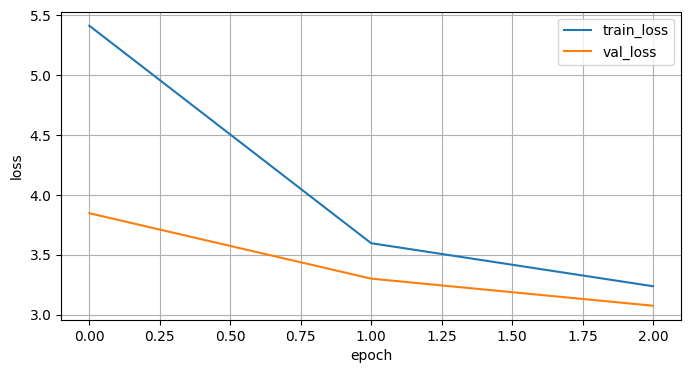

In [9]:

# =========================
# OPTIONAL: LOSS CURVES
# =========================

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
# =========================
# INFERENCE HELPERS
# =========================

def clean_prediction_text(text: str) -> str:
    text = text.replace("<pad>", "")
    text = text.replace("</s>", "")
    text = text.replace("<s>", "")
    return text.strip()

def parse_tagged_sequence(text: str):
    text = clean_prediction_text(text)
    text = text.replace(TASK_TOKEN, "", 1).strip()

    token_re = re.compile(r"</?s_[^>]+>")
    root = {}
    stack = [("__root__", root)]
    pos = 0

    for m in token_re.finditer(text):
        token = m.group()
        content = text[pos:m.start()]
        if content.strip():
            parent_name, parent_obj = stack[-1]
            if isinstance(parent_obj, dict):
                parent_obj.setdefault("__text__", "")
                parent_obj["__text__"] += content.strip()

        if token.startswith("</s_"):
            if len(stack) > 1:
                stack.pop()
        else:
            key = token[3:-1]  # <s_key> -> key
            if key == "item":
                new_obj = {}
                parent_name, parent_obj = stack[-1]
                if isinstance(parent_obj, dict):
                    parent_obj.setdefault("item", [])
                    parent_obj["item"].append(new_obj)
                elif isinstance(parent_obj, list):
                    parent_obj.append(new_obj)
                stack.append((key, new_obj))
            else:
                new_obj = {}
                parent_name, parent_obj = stack[-1]
                if isinstance(parent_obj, dict):
                    if key in parent_obj:
                        # если ключ повторяется, превращаем в список
                        if not isinstance(parent_obj[key], list):
                            parent_obj[key] = [parent_obj[key]]
                        parent_obj[key].append(new_obj)
                    else:
                        parent_obj[key] = new_obj
                stack.append((key, new_obj))
        pos = m.end()

    if pos < len(text):
        tail = text[pos:].strip()
        if tail:
            parent_name, parent_obj = stack[-1]
            if isinstance(parent_obj, dict):
                parent_obj.setdefault("__text__", "")
                parent_obj["__text__"] += tail

    def simplify(obj):
        if isinstance(obj, dict):
            # item list
            if set(obj.keys()) == {"__text__"}:
                return obj["__text__"]
            out = {}
            for k, v in obj.items():
                if k == "__text__":
                    txt = v.strip()
                    if txt and not out:
                        return txt
                    if txt:
                        out["value"] = txt
                elif k == "item":
                    out["items"] = [simplify(x) for x in v]
                else:
                    out[k] = simplify(v)
            return out
        elif isinstance(obj, list):
            return [simplify(x) for x in obj]
        else:
            return obj

    parsed = simplify(root)
    return parsed if parsed else None

def try_parse_donut(text: str):
    try:
        return parse_tagged_sequence(text)
    except Exception:
        return None

def try_parse_gt_json(text: str):
    try:
        return json.loads(text)
    except Exception:
        return None

def canonical_json(obj):
    return json.dumps(obj, ensure_ascii=False, sort_keys=True, separators=(",", ":"))

def normalize_text_for_compare(gt_json_text: str, pred_text: str) -> str:
    pred_obj = try_parse_donut(pred_text)
    if pred_obj is not None:
        return canonical_json(pred_obj)
    return clean_prediction_text(pred_text)

def flatten_json(obj, prefix=""):
    items = []
    if isinstance(obj, dict):
        for key in sorted(obj.keys()):
            new_prefix = f"{prefix}.{key}" if prefix else str(key)
            items.extend(flatten_json(obj[key], new_prefix))
    elif isinstance(obj, list):
        for i, value in enumerate(obj):
            new_prefix = f"{prefix}[{i}]"
            items.extend(flatten_json(value, new_prefix))
    else:
        items.append(f"{prefix}={obj}")
    return items

def field_f1(gt_json_text: str, pred_text: str) -> float:
    gt_obj = try_parse_gt_json(gt_json_text)
    pred_obj = try_parse_donut(pred_text)

    if gt_obj is None or pred_obj is None:
        return 0.0

    gt_set = set(flatten_json(gt_obj))
    pred_set = set(flatten_json(pred_obj))

    if len(gt_set) == 0 and len(pred_set) == 0:
        return 1.0

    tp = len(gt_set & pred_set)
    fp = len(pred_set - gt_set)
    fn = len(gt_set - pred_set)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

def similarity_score(gt_json_text: str, pred_text: str) -> float:
    gt_obj = try_parse_gt_json(gt_json_text)
    gt_norm = canonical_json(gt_obj) if gt_obj is not None else gt_json_text
    pred_norm = normalize_text_for_compare(gt_json_text, pred_text)
    return difflib.SequenceMatcher(None, gt_norm, pred_norm).ratio()

def exact_json_match(gt_json_text: str, pred_text: str) -> int:
    gt_obj = try_parse_gt_json(gt_json_text)
    pred_obj = try_parse_donut(pred_text)
    if gt_obj is None or pred_obj is None:
        return 0
    return int(canonical_json(gt_obj) == canonical_json(pred_obj))

def predict_document(model_, image, max_length=384, image_size=(960, 720)):
    model_.eval()
    model_ = model_.to(device)

    image = image.convert("RGB").resize(image_size)

    pixel_values = processor(
        images=image,
        return_tensors="pt"
    ).pixel_values.to(device)

    decoder_input_ids = processor.tokenizer(
        TASK_TOKEN,
        add_special_tokens=False,
        return_tensors="pt"
    ).input_ids.to(device)

    decoder_attention_mask = torch.ones_like(decoder_input_ids).to(device)

    with torch.no_grad():
        outputs = model_.generate(
            pixel_values=pixel_values,
            decoder_input_ids=decoder_input_ids,
            decoder_attention_mask=decoder_attention_mask,
            max_length=max_length,
            min_new_tokens=8,
            num_beams=4,
            early_stopping=True,
            pad_token_id=pad_token_id,
            eos_token_id=eos_token_id,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            length_penalty=0.9,
        )

    pred = processor.batch_decode(outputs, skip_special_tokens=False)[0]

    model_ = model_.cpu()
    gc.collect()
    torch.cuda.empty_cache()

    return pred


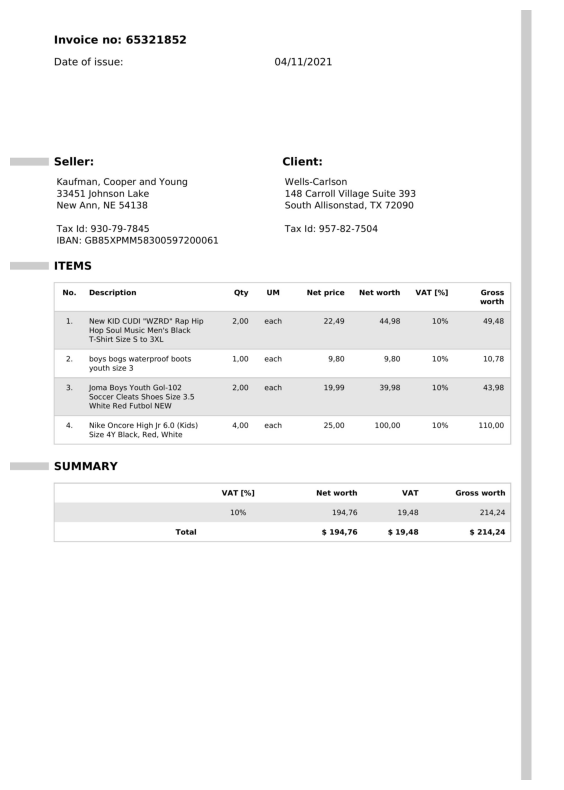

Example #0
GT:
<s_invoice><s_header><s_invoice_no>65321852</s_invoice_no><s_invoice_date>04/11/2021</s_invoice_date><s_seller>Kaufman, Cooper and Young 33451 Johnson Lake New Ann, NE 54138</s_seller><s_client>Wells-Carlson 148 Carroll Village Suite 393 South Allisonstad, TX 72090</s_client><s_seller_tax_id>930-79-7845</s_seller_tax_id><s_client_tax_id>957-82-7504</s_client_tax_id><s_iban>GB85XPMM58300597200061</s_iban></s_header><s_items><s_item><s_item_desc>New KID CUDI "WZRD" Rap Hip Hop Soul Music Men's Black T-Shirt Size S to 3XL</s_item_desc><s_item_qty>2,00</s_item_qty><s_item_net_price>22,49</s_item_net_price><s_item_net_worth>44,98</s_item_net_worth><s_item_vat>10%</s_item_vat><s_item_gross_worth>49,48</s_item_gross_worth></s_item><s_item><s_item_desc>boys bogs waterproof boots youth size 3</s_item_desc><s_item_qty>1,00</s_item_qty><s_item_net_price>9,80</s_item_net_price><s_item_net_worth>9,80</s_item_net_worth><s_item_vat>10%</s_item_vat><s_item_gross_worth>10,78</s_item_gros

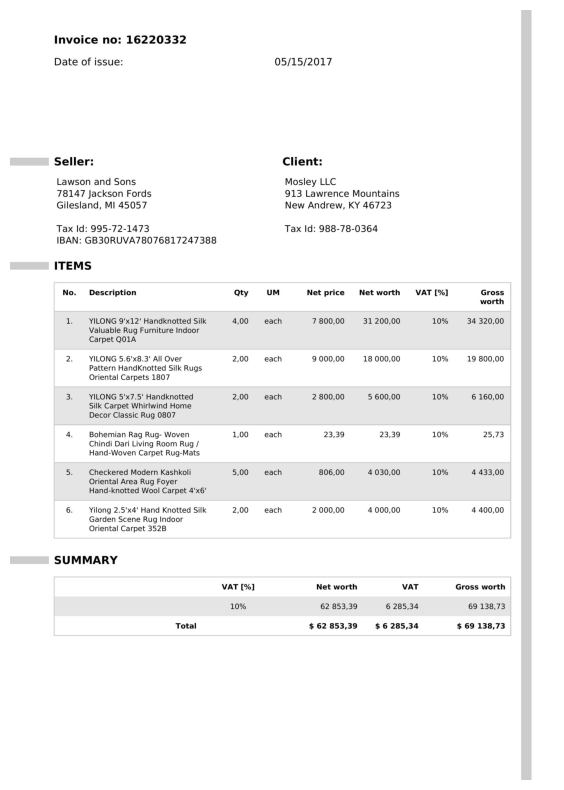

Example #1
GT:
<s_invoice><s_invoice_no>16220332</s_invoice_no><s_invoice_date>05/15/2017</s_invoice_date><s_seller>Lawson and Sons 78147 Jackson Fords Gilesland, MI 45057</s_seller><s_client>Mosley LLC 913 Lawrence Mountains New Andrew, KY 46723</s_client><s_seller_tax_id>995-72-1473</s_seller_tax_id><s_client_tax_id>988-78-0364</s_client_tax_id><s_iban>GB30RUVA78076817247388</s_iban><s_item_desc>Yilong 2.5'x4' Hand Knotted Silk Garden Scene Rug Indoor Oriental Carpet 352B</s_item_desc><s_item_qty>2,00</s_item_qty><s_item_net_price>2 000,00</s_item_net_price><s_item_net_worth>4000,00</s_item_net_worth><s_item_vat>10%</s_item_vat><s_item_gross_worth>4 400,00</s_item_gross_worth><s_total_net_worth>$62853,39</s_total_net_worth><s_total_vat>$6285,34</s_total_vat><s_total_gross_worth>$ 69138,73</s_total_gross_worth>

PRED:
<s_invoice> 6 285,332 Outubro Lawson and Sons 78147 Jackson Fords Gilesland, MI 45057懷疑 Mosley LLC 913 Lawrence Mountains New Andrew, KY 46723 Trykk 995-72-1473 rgan: GB

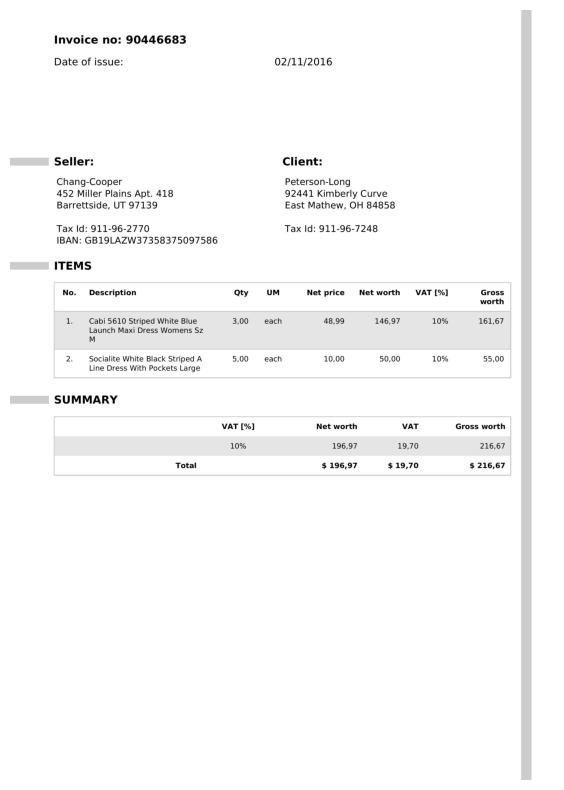

Example #2
GT:
<s_invoice><s_header><s_invoice_no>90446683</s_invoice_no><s_invoice_date>02/11/2016</s_invoice_date><s_seller>Chang-Cooper 452 Miller Plains Apt. 418 Barrettside, UT 97139</s_seller><s_client>Peterson-Long 92441 Kimberly Curve East Mathew, OH 84858</s_client><s_seller_tax_id>911-96-2770</s_seller_tax_id><s_client_tax_id>911-96-7248</s_client_tax_id><s_iban>GB19LAZW37358375097586</s_iban></s_header><s_items><s_item><s_item_desc>Cabi 5610 Striped White Blue Launch Maxi Dress Womens Sz</s_item_desc><s_item_qty>3,00</s_item_qty><s_item_net_price>48,99</s_item_net_price><s_item_net_worth>146,97</s_item_net_worth><s_item_vat>10%</s_item_vat><s_item_gross_worth>161,67</s_item_gross_worth></s_item><s_item><s_item_desc>Socialite White Black Striped A Line Dress With Pockets Large</s_item_desc><s_item_qty>5,00</s_item_qty><s_item_net_price>10,00</s_item_net_price><s_item_net_worth>50,00</s_item_net_worth><s_item_vat>10%</s_item_vat><s_item_gross_worth>55,00</s_item_gross_worth></

In [11]:

# =========================
# QUICK VISUAL CHECK
# =========================

for i in range(min(3, len(val_data))):
    image = val_data[i]["image"]
    gt = val_data[i]["target_text"]
    pred = predict_document(full_ft_model, image, max_length=MAX_LENGTH, image_size=IMAGE_SIZE)

    plt.figure(figsize=(8, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("=" * 100)
    print(f"Example #{i}")
    print("GT:")
    print(gt[:1000])
    print("\nPRED:")
    print(pred[:1000])


In [12]:
# =========================
# CLEAN COMPARISON: BASE VS FULL FT
# =========================

results = []

for idx in range(min(N_COMPARE, len(val_data))):
    image = val_data[idx]["image"]
    gt_json_text = val_data[idx]["gt_json_text"]

    base_pred = predict_document(base_model, image, max_length=MAX_LENGTH, image_size=IMAGE_SIZE)
    full_pred = predict_document(full_ft_model, image, max_length=MAX_LENGTH, image_size=IMAGE_SIZE)

    row = {
        "idx": idx,

        "base_similarity": similarity_score(gt_json_text, base_pred),
        "full_similarity": similarity_score(gt_json_text, full_pred),

        "base_field_f1": field_f1(gt_json_text, base_pred),
        "full_field_f1": field_f1(gt_json_text, full_pred),

        "base_exact_json": exact_json_match(gt_json_text, base_pred),
        "full_exact_json": exact_json_match(gt_json_text, full_pred),

        "base_valid_json": int(try_parse_donut(base_pred) is not None),
        "full_valid_json": int(try_parse_donut(full_pred) is not None),
    }

    results.append(row)

results_df = pd.DataFrame(results)
display(results_df.head())

print("=" * 100)
print("AVERAGES")
print("=" * 100)
print(f"Average similarity  | base: {results_df['base_similarity'].mean():.4f} | full_ft: {results_df['full_similarity'].mean():.4f}")
print(f"Average field F1    | base: {results_df['base_field_f1'].mean():.4f} | full_ft: {results_df['full_field_f1'].mean():.4f}")
print(f"Exact JSON match    | base: {results_df['base_exact_json'].mean():.4f} | full_ft: {results_df['full_exact_json'].mean():.4f}")
print(f"Valid JSON rate     | base: {results_df['base_valid_json'].mean():.4f} | full_ft: {results_df['full_valid_json'].mean():.4f}")

base_wins = (results_df["base_field_f1"] > results_df["full_field_f1"]).sum()
full_wins = (results_df["full_field_f1"] > results_df["base_field_f1"]).sum()
ties = (results_df["full_field_f1"] == results_df["base_field_f1"]).sum()

print()
print(f"By field F1 -> base wins: {base_wins}, full_ft wins: {full_wins}, ties: {ties}")


,idx,base_similarity,full_similarity,base_field_f1,full_field_f1,base_exact_json,full_exact_json,base_valid_json,full_valid_json
0,0,0.029478,0.137979,0.0,0.0,0,0,1,1
1,1,0.056761,0.209009,0.0,0.0,0,0,1,1
2,2,0.125276,0.130612,0.0,0.0,0,0,1,1
3,3,0.063299,0.151917,0.0,0.0,0,0,1,1
4,4,0.095522,0.298969,0.0,0.0,0,0,1,1


AVERAGES
Average similarity  | base: 0.0679 | full_ft: 0.1603
Average field F1    | base: 0.0000 | full_ft: 0.0000
Exact JSON match    | base: 0.0000 | full_ft: 0.0000
Valid JSON rate     | base: 1.0000 | full_ft: 1.0000

By field F1 -> base wins: 0, full_ft wins: 0, ties: 20


In [13]:

# =========================
# OPTIONAL: SHOW BEST / WORST EXAMPLES
# =========================

if len(results_df) > 0:
    merged = results_df.copy()
    merged["delta_field_f1"] = merged["full_field_f1"] - merged["base_field_f1"]
    display(merged.sort_values("delta_field_f1", ascending=False).head(10))
    display(merged.sort_values("delta_field_f1", ascending=True).head(10))


,idx,base_similarity,full_similarity,base_field_f1,full_field_f1,base_exact_json,full_exact_json,base_valid_json,full_valid_json,delta_field_f1
0,0,0.029478,0.137979,0.0,0.0,0,0,1,1,0.0
1,1,0.056761,0.209009,0.0,0.0,0,0,1,1,0.0
2,2,0.125276,0.130612,0.0,0.0,0,0,1,1,0.0
3,3,0.063299,0.151917,0.0,0.0,0,0,1,1,0.0
4,4,0.095522,0.298969,0.0,0.0,0,0,1,1,0.0
5,5,0.086957,0.120750,0.0,0.0,0,0,1,1,0.0
6,6,0.101061,0.114634,0.0,0.0,0,0,1,1,0.0
7,7,0.059623,0.128828,0.0,0.0,0,0,1,1,0.0
8,8,0.021433,0.215223,0.0,0.0,0,0,1,1,0.0
9,9,0.021600,0.044622,0.0,0.0,0,0,1,1,0.0


,idx,base_similarity,full_similarity,base_field_f1,full_field_f1,base_exact_json,full_exact_json,base_valid_json,full_valid_json,delta_field_f1
0,0,0.029478,0.137979,0.0,0.0,0,0,1,1,0.0
1,1,0.056761,0.209009,0.0,0.0,0,0,1,1,0.0
2,2,0.125276,0.130612,0.0,0.0,0,0,1,1,0.0
3,3,0.063299,0.151917,0.0,0.0,0,0,1,1,0.0
4,4,0.095522,0.298969,0.0,0.0,0,0,1,1,0.0
5,5,0.086957,0.120750,0.0,0.0,0,0,1,1,0.0
6,6,0.101061,0.114634,0.0,0.0,0,0,1,1,0.0
7,7,0.059623,0.128828,0.0,0.0,0,0,1,1,0.0
8,8,0.021433,0.215223,0.0,0.0,0,0,1,1,0.0
9,9,0.021600,0.044622,0.0,0.0,0,0,1,1,0.0
